# NYC Yellow Taxi — DuckDB + MotherDuck

Queries `sample_data.nyc.taxi` on MotherDuck through a local DuckDB engine.
Requires `motherduck_token` in `../.env`.

In [1]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), '.env'))
load_dotenv()  # fallback if launched from repo root

token = os.environ['motherduck_token']
con = duckdb.connect(f'md:?motherduck_token={token}')
print('duckdb', duckdb.__version__)
print('local check:', con.sql('SELECT 42 AS answer').fetchone())

duckdb 1.5.2
local check: (42,)


## 1. Connection sanity check + schema

In [2]:
row_count = con.sql('SELECT COUNT(*) FROM sample_data.nyc.taxi').fetchone()[0]
print(f'sample_data.nyc.taxi rows: {row_count:,}')
con.sql('DESCRIBE sample_data.nyc.taxi').df()

sample_data.nyc.taxi rows: 3,252,717


,column_name,column_type,null,key,default,extra
0,VendorID,BIGINT,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,DOUBLE,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,RatecodeID,DOUBLE,YES,None,None,None
6,store_and_fwd_flag,VARCHAR,YES,None,None,None
7,PULocationID,BIGINT,YES,None,None,None
8,DOLocationID,BIGINT,YES,None,None,None
9,payment_type,BIGINT,YES,None,None,None


In [3]:
con.sql('FROM sample_data.nyc.taxi LIMIT 5').df()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2022-11-04 23:13:01,2022-11-04 23:25:38,4.0,1.78,1.0,N,230,239,1,10.0,0.5,0.5,2.76,0.0,0.3,16.56,2.5,0.0
1,2,2022-11-04 23:32:02,2022-11-04 23:41:31,1.0,1.09,1.0,N,142,141,2,7.5,0.5,0.5,0.00,0.0,0.3,11.30,2.5,0.0
2,1,2022-11-04 23:17:40,2022-11-04 23:25:40,2.0,0.80,1.0,N,230,68,1,6.5,3.0,0.5,2.05,0.0,0.3,12.35,2.5,0.0
3,2,2022-11-04 23:19:24,2022-11-04 23:32:21,1.0,1.62,1.0,N,163,90,1,10.0,0.5,0.5,2.76,0.0,0.3,16.56,2.5,0.0
4,2,2022-11-04 23:40:42,2022-11-04 23:52:26,1.0,2.08,1.0,N,186,143,1,10.0,0.5,0.5,2.50,0.0,0.3,16.30,2.5,0.0


## 2. Trip stats summary

In [4]:
con.sql("""
    SELECT
        COUNT(*)                       AS trips,
        ROUND(AVG(fare_amount), 2)     AS avg_fare,
        ROUND(MEDIAN(fare_amount), 2)  AS median_fare,
        ROUND(AVG(trip_distance), 2)   AS avg_distance_mi,
        ROUND(AVG(passenger_count), 2) AS avg_passengers,
        ROUND(AVG(total_amount), 2)    AS avg_total
    FROM sample_data.nyc.taxi
    WHERE fare_amount > 0 AND trip_distance > 0
""").df()

,trips,avg_fare,median_fare,avg_distance_mi,avg_passengers,avg_total
0,3171186,15.16,10.5,6.45,1.39,22.17


In [5]:
con.sql("""
    SELECT payment_type, COUNT(*) AS trips,
           ROUND(AVG(total_amount), 2) AS avg_total
    FROM sample_data.nyc.taxi
    GROUP BY payment_type
    ORDER BY trips DESC
""").df()

,payment_type,trips,avg_total
0,1,2483550,22.99
1,2,598081,18.26
2,0,121958,29.30
3,4,31334,1.63
4,3,17793,7.58
5,5,1,0.00


## 3. Daily trip volume

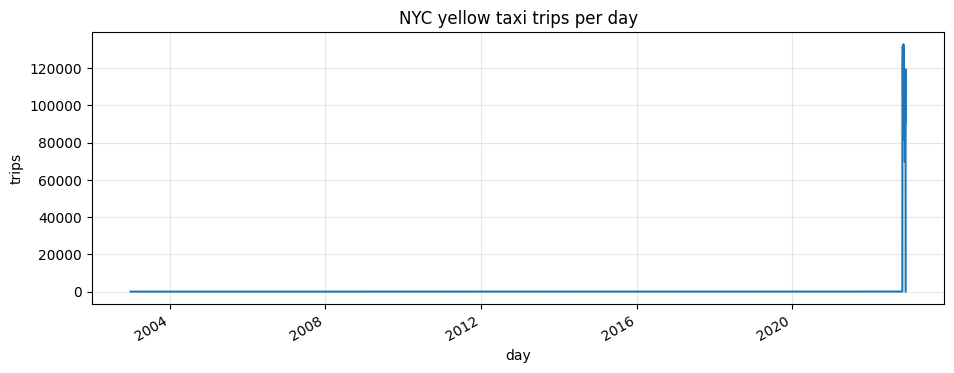

,day,trips
0,2002-12-31,1
1,2008-12-31,2
2,2009-01-01,3
3,2022-10-31,34
4,2022-11-01,120506


In [6]:
daily = con.sql("""
    SELECT date_trunc('day', tpep_pickup_datetime) AS day,
           COUNT(*) AS trips
    FROM sample_data.nyc.taxi
    GROUP BY 1
    ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily['day'], daily['trips'])
ax.set_title('NYC yellow taxi trips per day')
ax.set_xlabel('day')
ax.set_ylabel('trips')
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()
daily.head()

## 4. Top pickup locations

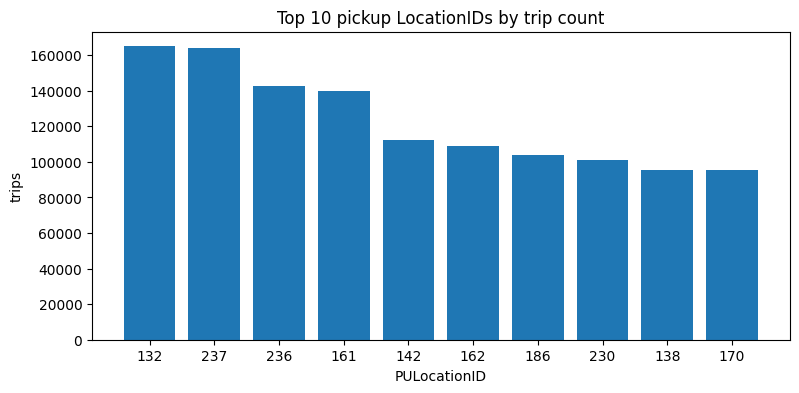

,PULocationID,trips,avg_fare
0,132,164957,45.72
1,237,163888,10.07
2,236,142776,10.69
3,161,140025,12.45
4,142,112137,11.31
5,162,109137,12.23
6,186,104008,12.98
7,230,101217,14.64
8,138,95320,31.55
9,170,95213,12.42


In [7]:
top = con.sql("""
    SELECT PULocationID,
           COUNT(*) AS trips,
           ROUND(AVG(fare_amount), 2) AS avg_fare
    FROM sample_data.nyc.taxi
    GROUP BY PULocationID
    ORDER BY trips DESC
    LIMIT 10
""").df()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(top['PULocationID'].astype(str), top['trips'])
ax.set_title('Top 10 pickup LocationIDs by trip count')
ax.set_xlabel('PULocationID')
ax.set_ylabel('trips')
plt.show()
top